<a href="https://colab.research.google.com/github/greensky0107/self_study/blob/main/Day50_DeepLearningMode_WeightInitialization_BatchNormalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10-2. 가중치 초기화 Weights Initialization

가중치 초기화 방법에 따라서 어떻게 달라지는지 살펴보기 위해 지정된 활성화 함수 activation과 초기화 initializer에 따라 모델을 생성하는 build_model 함수 정의

In [ ]:
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers, optimizers

def build_model(activation, initializer):
  model = models.Sequential()
  model.add(layers.Input(shape=(400, 20), name='input'))
  model.add(layers.Dense(20, activation=activation, name='hidden1',
                        kernel_initializer=initializer))
  model.add(layers.Dense(20, activation=activation, name='hidden2',
                        kernel_initializer=initializer))
  model.add(layers.Dense(20, activation=activation, name='hidden3',
                        kernel_initializer=initializer))
  model.add(layers.Dense(20, activation=activation, name='hidden4',
                        kernel_initializer=initializer))
  model.add(layers.Dense(20, activation=activation, name='hidden5',
                        kernel_initializer=initializer))
  model.compile(loss='sparse_categorical_crossentropy',
                optimizer=optimizers.SGD(),
                metrics=['accuracy'])
  return model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 682.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.8 MB/s eta 0:00:00


각 레이어마다 분포값을 히스토그램으로 출력하기 위한 show_layer 함수 지정

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import initializers, activations

## 이부분 matplotlib 업데이트 되면서 없어진 부분
sns.set_style('white')
# plt.style.use('seaborn-white')

def show_layer(model):
  input = np.random.randn(400, 20)

  plt.figure(figsize=(12, 6))
  for i in range(1, 6):
    name = 'hidden' + str(i)
    layer = model.get_layer(name)
    input = layer(input)
    plt.subplot(1, 6, i)
    plt.title(name)
    # 이부분을 이렇게 고쳐줘야 표가 나옵니다 -> numpy로 바꿔주면 계산속도 up
    plt.hist(input.numpy().flatten(), bins=20, range=(-1, 1))
    # plt.hist(input, 20, range=(-1, 1))
    plt.subplots_adjust(wspace=0.5, hspace=0.5)
  plt.show()

여러 활성화 함수들중 선형 함수의 가중치 초기화 방법에 따라 어떻게 분포가 달라지는 지 살펴봄.

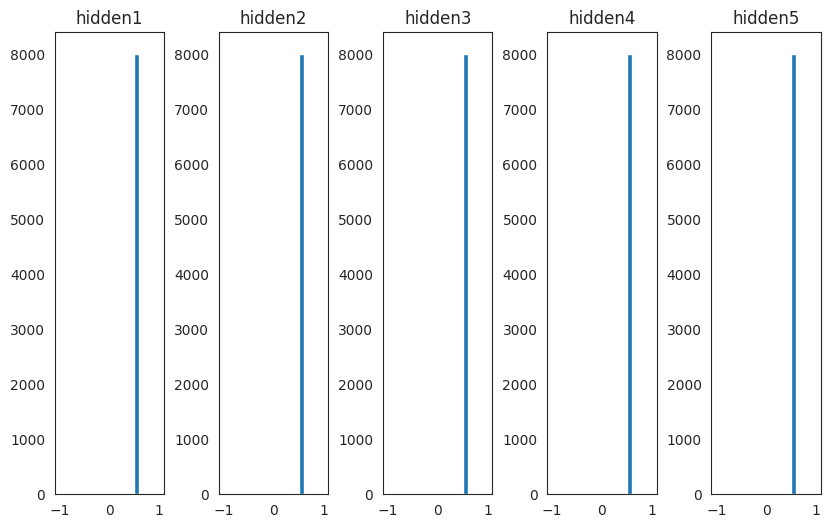

In [ ]:
# 제로 초기화 initializers.Zeros()를 이용
model = build_model(activations.sigmoid, initializers.Zeros())
show_layer(model)

# 가중치를 제로값으로 초기화할 경우 각 layer의 가중치 값 분포가 특정한 값으로만 몰려 있음.
# 가중치 값이 0일 경우에는 오차역전파에서 모든 가중치 값이 똑같이 갱신되어 학습이 올바르게 진행될 수 없음.
# 참고: 각 레이어의 값이 0.5에 몰려 있는 이유는 가중치 값이 활성화 함수로 사용한 sigmoid 함수를 통과하였기 때문. (sigmoid(0)=0.5)

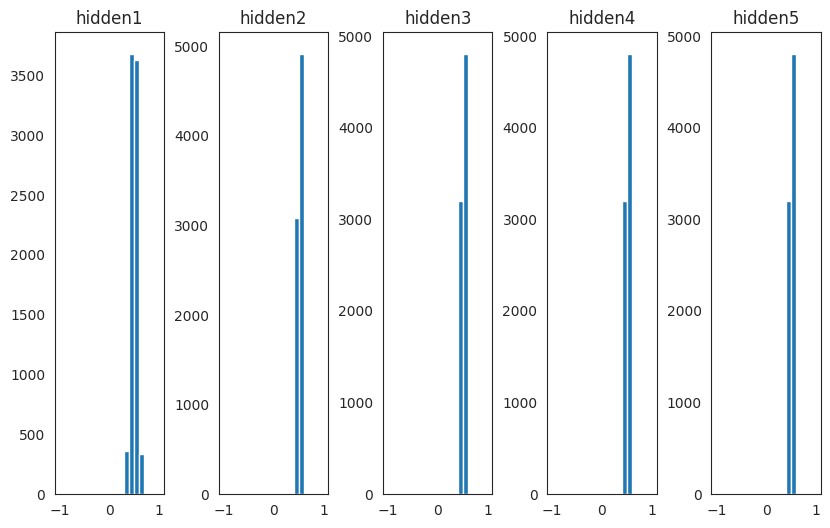

In [ ]:
# 정규분포 초기화  initializers.RandomNormal()를 통해
model = build_model(activations.sigmoid, initializers.RandomNormal())
show_layer(model)

# 정규분포를 따르도록 무작위 값을 초기화하면 제로 초기화보다는 분포가 퍼져있는 것을 알 수 있음
# 그러나 한 곳에 치우쳐 있기 때문에 여전히 신경망의 표현을 제한한다는 문제가 있음.

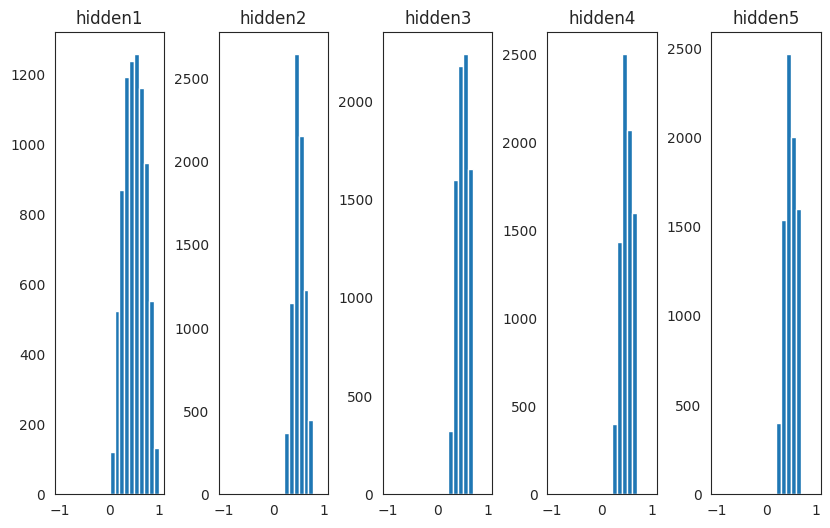

In [ ]:
# 균일분포 초기화 initializers.RandomUniform()를 통해
model = build_model(activations.sigmoid, initializers.GlorotNormal())
show_layer(model)

# 균일분포를 따르는 무작위 값으로 초기화한 결과도 제로 초기화보다는 분포가 퍼져있음
# 그러나 활성화 값이 균일하지 않으므로 역전파로 전해지는 기울기 값이 사라질 수 있음

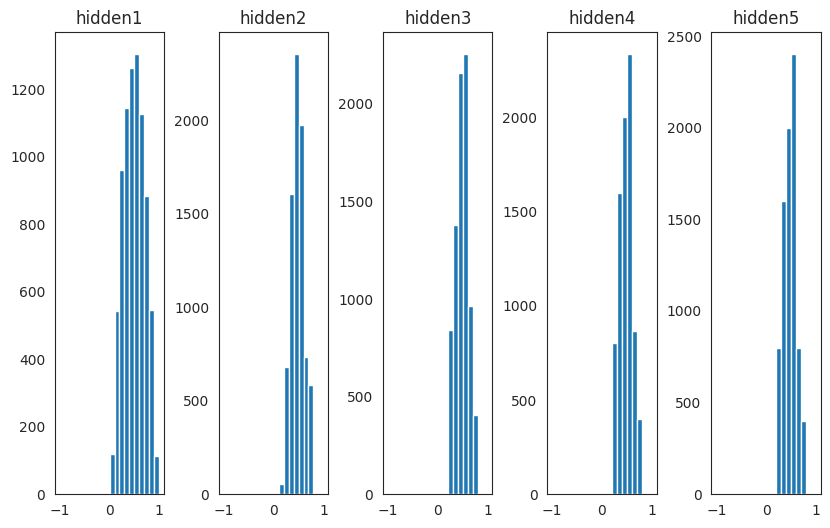

In [ ]:
# Xavier(Glorot) 정규분포 초기화  initializers.GlorotNormal()를 적용한 모델
model = build_model(activations.sigmoid, initializers.GlorotUniform())
show_layer(model)

# initializers.GlorotNormal()를 적용한 모델을 시각화한 결과를 보면 비교적 분포로 고르고 레이어마다 표현이 잘 되고 있음
# 더 많은 가중치에 역전파가 전달이 가능하게 됨 일반적으로 Xavier(Glorot) 방법은 활성화 함수가 선형함수인 경우에 매우 적합함.

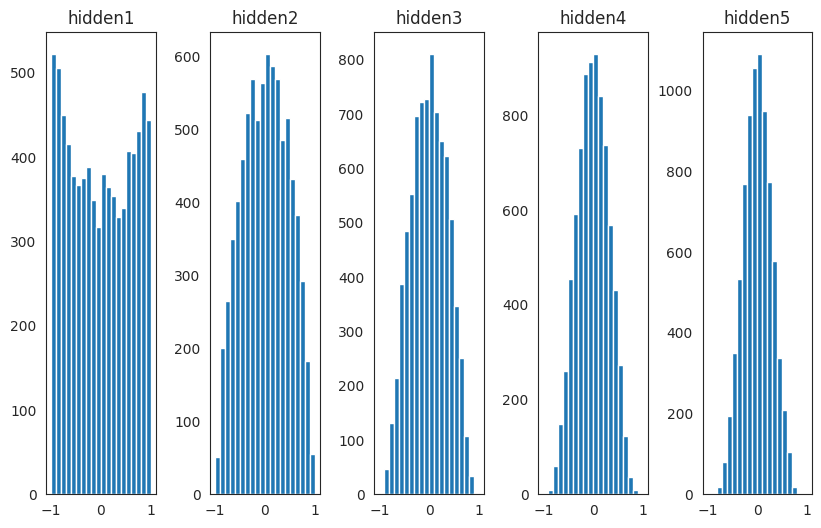

In [ ]:
# Xavier(Glorot) 균일분포 초기화 initializers.GlorotUniform()를 통해
model = build_model(activations.tanh, initializers.GlorotUniform())
show_layer(model)

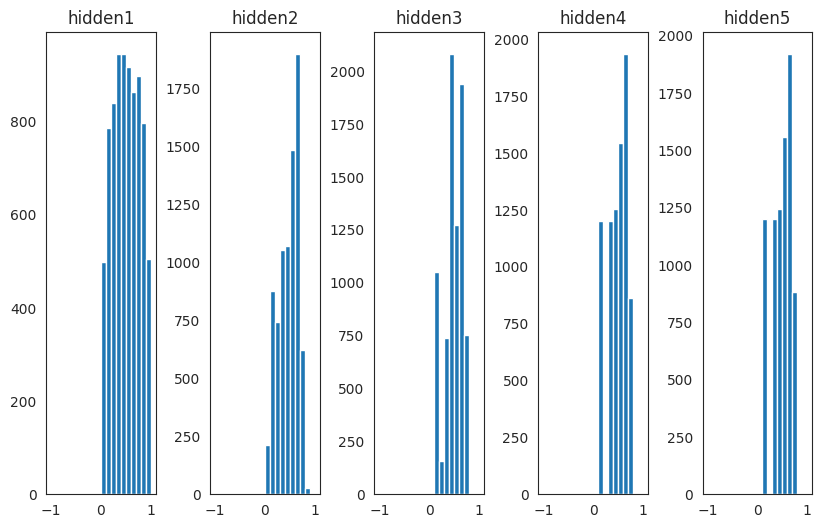

In [ ]:
# 활성화 함수를 sigmoid 대신 tanh를 적용한 결과, 좀 더 균일한 분포의 모습을 보임..

model = build_model(activations.sigmoid, initializers.HeNormal())
show_layer(model)

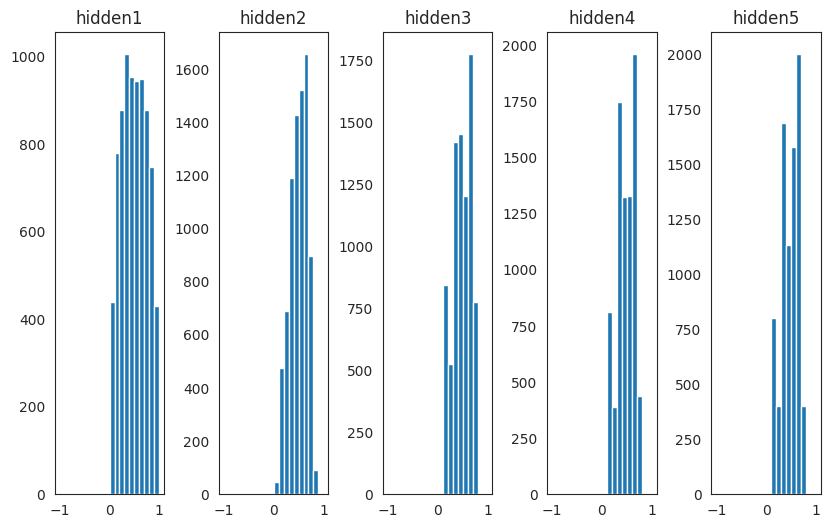

In [ ]:
# He 정규분포 초기화
# 활성화값 분포가 균일하게 분포되어 있음. 참고로 ReLU와 같은 비선형함수 일 때 더 적합하다고 알려진 초기화 방법.

model = build_model(activations.sigmoid, initializers.HeNormal())
show_layer(model)

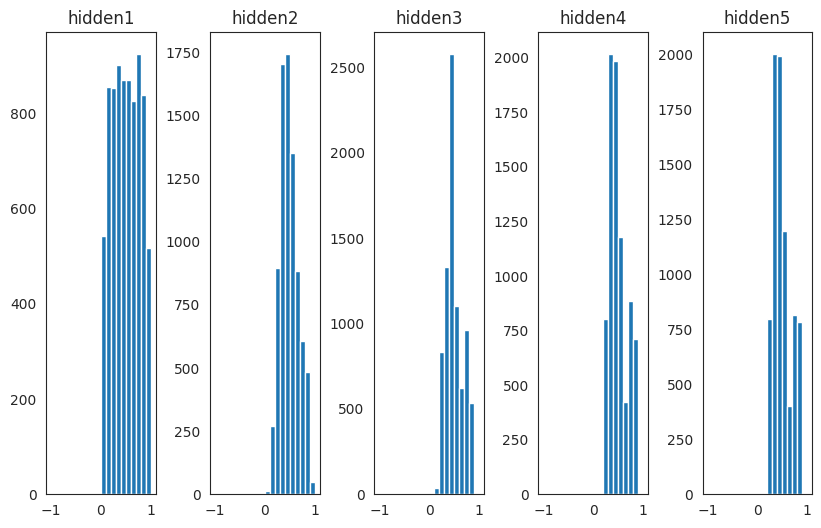

In [ ]:
# He 균일분포 초기화
# He 균일분포도 정규분포와 유사하게 가중치 값들이 잘 분포되어 있음을 알 수 있습니다.

model = build_model(activations.sigmoid, initializers.HeUniform())
show_layer(model)

여러 활성화 함수들중 비선형 함수로 구분하여 가중치 초기화 방법에 따라 어떻게 분포가 달라지는 지 살펴봄.

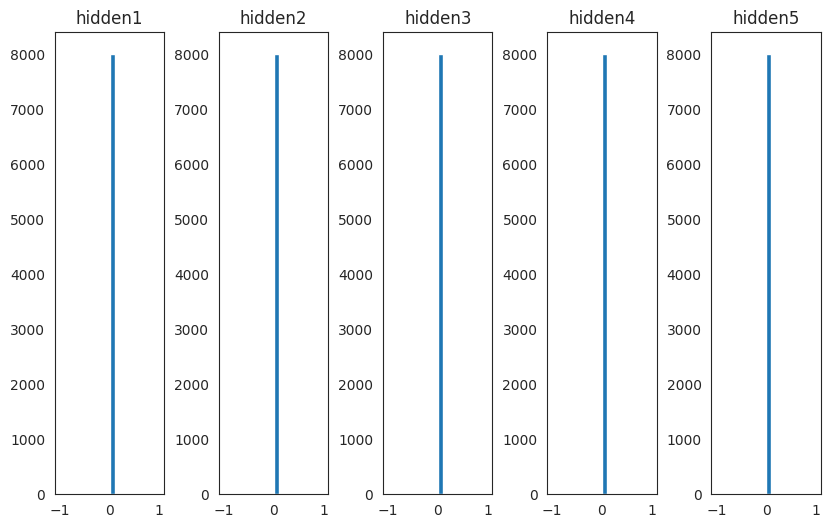

In [ ]:
# Zero 초기화.  activation 함수 relu
# 가중치를 제로값으로 초기화한 경우, 시각화 결과를 보면 레이어의 가중치 분포가 0에만 몰려 있음
# 활성화 함수로 relu를 사용하였기 때문에 0인 값은 그대로 0에만 머물게 됨.
# 참고: 각 레이어의 값이 0에 몰려 있는 이유는 가중치 값이 활성화 함수로 사용한 reLU 함수를 통과해서(relu(0)=0

model = build_model(activations.relu, initializers.Zeros())
show_layer(model)

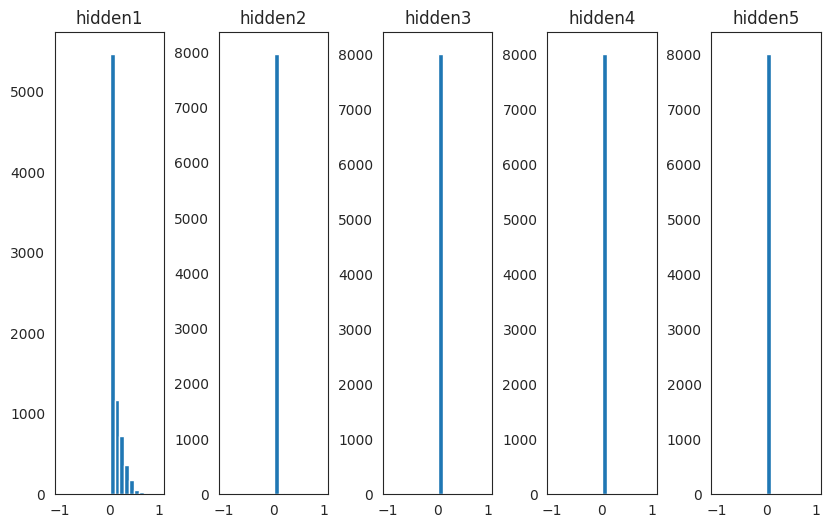

In [ ]:
# 정규분포 초기화

model = build_model(activations.relu, initializers.RandomNormal())
show_layer(model)

# 제로 초기화보다는 정규분포 초기화의 경우 분포가 퍼져있음
# 그러나 마찬가지로 hidden1 레이어를 제외하고는 0에 치우쳐 있는 문제발생

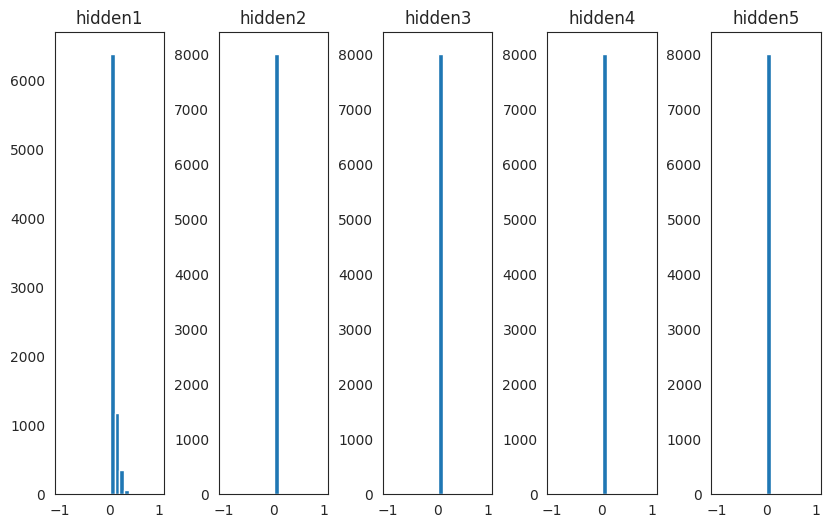

In [ ]:
# 균일분포 초기화

model = build_model(activations.relu, initializers.RandomUniform())
show_layer(model)

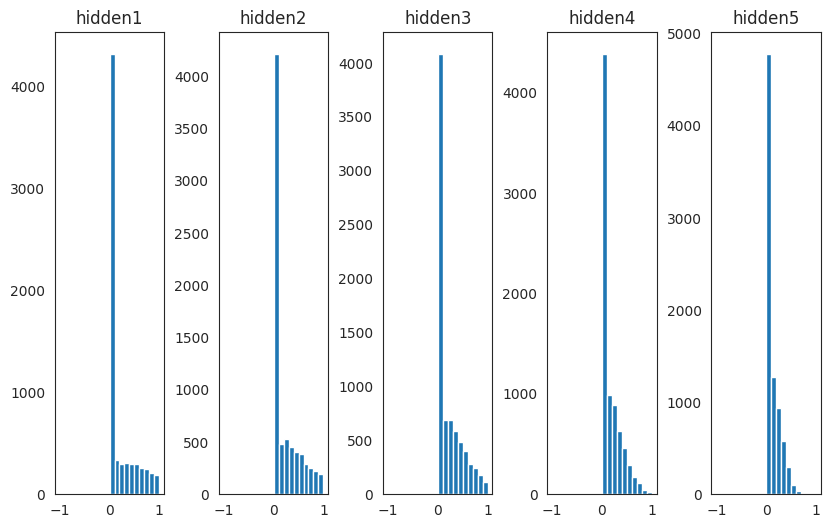

In [ ]:
# Xavier(Glorot) 정규분포 초기화
model = build_model(activations.relu, initializers.GlorotNormal())
show_layer(model)

# Xavier 초기화 방법은 relu 특성상 0인 값이 많지만, 전체 레이어를 보더라도 어느정도 분포가 퍼져있는 것을 알 수 있음.

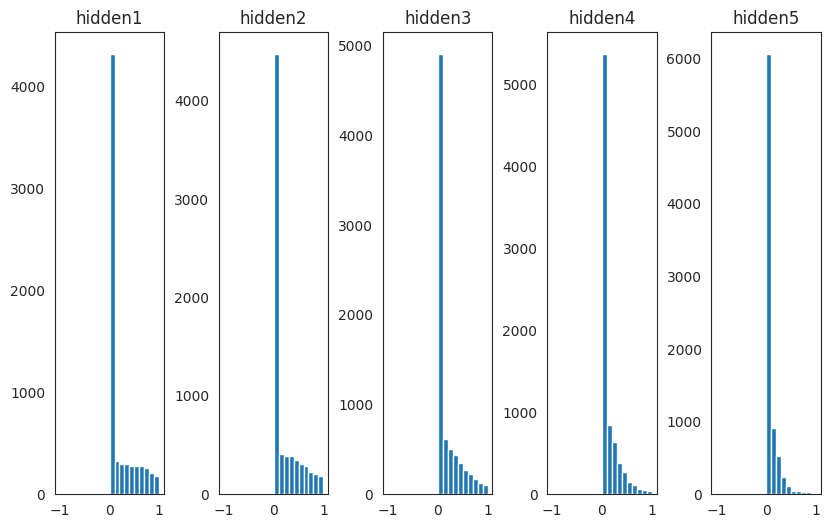

In [ ]:
# Xavier(Glorot) 균일분포 초기화
model = build_model(activations.relu, initializers.GlorotUniform())
show_layer(model)

# 균일분포도 정규분포와 유사한 형태의 분포를 보여줌

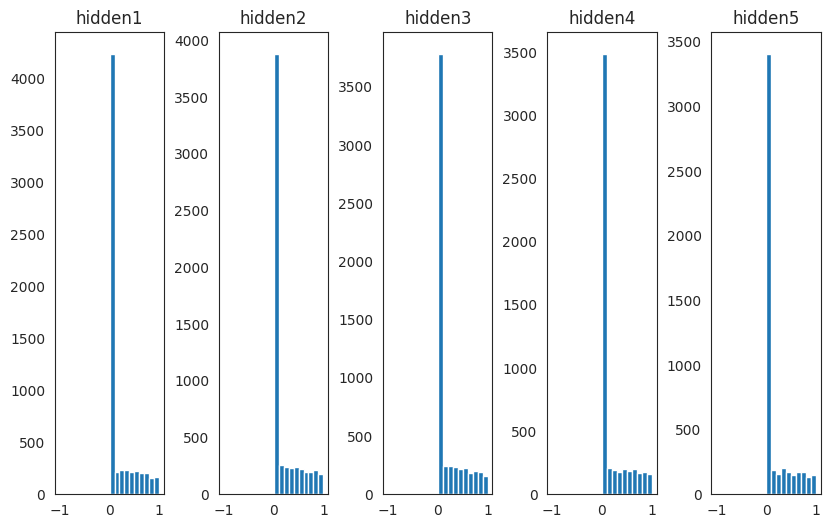

In [ ]:
# He 정규분포 초기화
model = build_model(activations.relu, initializers.HeNormal())
show_layer(model)

# He 초기화는 일반적으로 비선형 함수에 더 적합하다고 알려져있으며, 시각화된 결과도 어느정도 분포가 고르게 형성되어 있음을 알 수 있음.

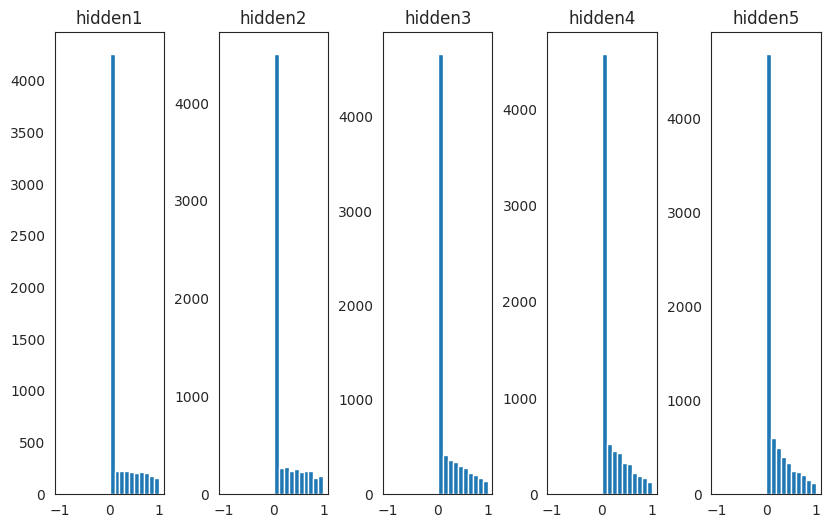

In [ ]:
# He 균일분포 초기화
model = build_model(activations.relu, initializers.HeUniform())
show_layer(model)
# 균일분포도 마찬가지로 정규분포와 유사한 모습을 보여주고 있음

# 10-3.Reuters Deep Learning 예제 가중치 초기화 연습


Reuters Dataset은 뉴스 기사를 모아놓은 것으로 주제 분류를 위해 자주 사용됨.

데이터셋은 뉴스 기사 텍스트와 46개의 토픽으로 구성되어 있음.

Reuters 데이터셋으로 가중치 초기화 실습..

1.데이터 로드 및 전처리

  Reuters 뉴스 기사 데이터를 Keras에서 reuters.load_data() 함수를 통해 다운로드.
  
  본 예제에서는 num_words를 10000개로 제한하여 데이터를 로드.

  8,982개의 훈련 데이터셋과 2,246개의 테스트 데이터셋으로 구분되어 있고, 레이블을 통해 뉴스 기사의 주제로 46개가 있음을 확인

In [ ]:
from keras.datasets import reuters
import numpy as np

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

print(len(train_data))
print(len(test_data))
print(len(set(train_labels)))

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
8982
2246
46


In [ ]:
# Reuters 데이터셋도 단어 인덱스로만 구성되어 있기 때문에 reuters.get_word_index() 함수를 통해 얻은 단어 인덱스 딕셔너리를 이용해 인덱스를 단어들로 변환이 가능

word_index = reuters.get_word_index()
word_index

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


{'mdbl': 10996,
 'fawc': 16260,
 'degussa': 12089,
 'woods': 8803,
 'hanging': 13796,
 'localized': 20672,
 'sation': 20673,
 'chanthaburi': 20675,
 'refunding': 10997,
 'hermann': 8804,
 'passsengers': 20676,
 'stipulate': 20677,
 'heublein': 8352,
 'screaming': 20713,
 'tcby': 16261,
 'four': 185,
 'grains': 1642,
 'broiler': 20680,
 'wooden': 12090,
 'wednesday': 1220,
 'highveld': 13797,
 'duffour': 7593,
 '0053': 20681,
 'elections': 3914,
 '270': 2563,
 '271': 3551,
 '272': 5113,
 '273': 3552,
 '274': 3400,
 'rudman': 7975,
 '276': 3401,
 '277': 3478,
 '278': 3632,
 '279': 4309,
 'dormancy': 9381,
 'errors': 7247,
 'deferred': 3086,
 'sptnd': 20683,
 'cooking': 8805,
 'stratabit': 20684,
 'designing': 16262,
 'metalurgicos': 20685,
 'databank': 13798,
 '300er': 20686,
 'shocks': 20687,
 'nawg': 7972,
 'tnta': 20688,
 'perforations': 20689,
 'affiliates': 2891,
 '27p': 20690,
 'ching': 16263,
 'china': 595,
 'wagyu': 16264,
 'affiliated': 3189,
 'chino': 16265,
 'chinh': 16266,
 '

In [ ]:
# 인덱스 단어 딕셔너리 형태로 만들기 위해서 단어 인덱스 딕셔너리를 역으로 변환.
index_word = dict([(value, key) for (key, value) in word_index.items()])
index_word

{10996: 'mdbl',
 16260: 'fawc',
 12089: 'degussa',
 8803: 'woods',
 13796: 'hanging',
 20672: 'localized',
 20673: 'sation',
 20675: 'chanthaburi',
 10997: 'refunding',
 8804: 'hermann',
 20676: 'passsengers',
 20677: 'stipulate',
 8352: 'heublein',
 20713: 'screaming',
 16261: 'tcby',
 185: 'four',
 1642: 'grains',
 20680: 'broiler',
 12090: 'wooden',
 1220: 'wednesday',
 13797: 'highveld',
 7593: 'duffour',
 20681: '0053',
 3914: 'elections',
 2563: '270',
 3551: '271',
 5113: '272',
 3552: '273',
 3400: '274',
 7975: 'rudman',
 3401: '276',
 3478: '277',
 3632: '278',
 4309: '279',
 9381: 'dormancy',
 7247: 'errors',
 3086: 'deferred',
 20683: 'sptnd',
 8805: 'cooking',
 20684: 'stratabit',
 16262: 'designing',
 20685: 'metalurgicos',
 13798: 'databank',
 20686: '300er',
 20687: 'shocks',
 7972: 'nawg',
 20688: 'tnta',
 20689: 'perforations',
 2891: 'affiliates',
 20690: '27p',
 16263: 'ching',
 595: 'china',
 16264: 'wagyu',
 3189: 'affiliated',
 16265: 'chino',
 16266: 'chinh',
 2

In [ ]:
# train_data[0]의 각 인덱스에 매핑되는 단어들로 연결하여 하나의 리뷰를 만들어 봄.
news = ' '.join([str(i) for i in train_data[0]])
news

'1 2 2 8 43 10 447 5 25 207 270 5 3095 111 16 369 186 90 67 7 89 5 19 102 6 19 124 15 90 67 84 22 482 26 7 48 4 49 8 864 39 209 154 6 151 6 83 11 15 22 155 11 15 7 48 9 4579 1005 504 6 258 6 272 11 15 22 134 44 11 15 16 8 197 1245 90 67 52 29 209 30 32 132 6 109 15 17 12'

In [ ]:
# 단어 인덱스에서 0은 패딩을 의미하는 토큰인 pad,
# 1은 문장의 시작을 의미하는 토큰인 sos,
# 2는 OOV(Out Of Vocabulary)를 의미하는 토큰인 unk으로 지정되어 있음
# 그러므로 i-3으로 인덱스를 맞춰주고, 해당 토큰들은 ?로 대체

news = ' '.join([index_word.get(i-3, '?') for i in train_data[0]])
news

'? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3'

In [ ]:
# 딥러닝 모델의 학습에 사용하기 위해서는 텍스트 데이터를 벡터로 변환해야 함.
# 일반적으로 자주 사용되는 원-핫 인코딩(one-hot encoding)을 이용해 텍스트를 0과 1의 벡터로 변환

def one_hot_encoding(data, dim=10000):
  results = np.zeros((len(data), dim))
  for i, d in enumerate(data):
    results[i, d] = 1.
  return results

x_train = one_hot_encoding(train_data)
x_test = one_hot_encoding(test_data)

print(x_train[0])

[0. 1. 1. ... 0. 0. 0.]


In [ ]:
# Reuters 데이터셋에서 레이블은 46개의 주제를 구분하기 위한 인덱스로 구성됨.  무작위 레이블 확인
print(train_labels[5])
print(train_labels[15])
print(train_labels[25])
print(train_labels[35])
print(train_labels[45])

4
8
1
4
20


In [ ]:
# 뉴스 주제인 레이블도 원-핫 인코딩(범주형 인코딩)을 이용해 변환을 수행해야함
# Keras에서는 utils.to_categorical()을 사용.

from tensorflow.keras import utils

y_train = utils.to_categorical(train_labels)
y_test = utils.to_categorical(test_labels)

print(train_labels[5], y_train[5])
print(train_labels[15], y_train[15])
print(train_labels[25], y_train[25])

4 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
8 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


2.모델 구성

  Reuters 데이터셋을 주제별로 분류하기 위한 딥러닝 모델을 정의함.
  
  순차적으로 레이어를 추가하여 단순한 모델을 생성하기 위해 Sequential() 함수를 사용.

  첫번째는 유닛수 128개, 활성화 함수는 'relu', 입력 차원은 10000, 이름은 input인 Dense 레이어를 추가.
  
  두번째도 마찬가지로 유닛수 128개를 가지고, relu 활성화 함수를 사용하며 이름은 hidden인 Dense 레이어를 추가
  
  세번째는 뉴스 주제 갯수로 유닛수를 46개로 지정하고, 다중 분류이므로 활성화 함수는 softmax를 사용하고, 이름은 output으로 지정한 Dense 레이어를 추가.

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers

model = models.Sequential()
model.add(layers.Dense(128, activation='relu', input_shape=(10000, ), name='input'))
model.add(layers.Dense(128, activation='relu', name='hidden'))
model.add(layers.Dense(46, activation='softmax', name='output'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3.모델 컴파일 및 학습

  정의한 모델에 사용할 옵티마이저는 rmsprop를 사용하고, 손실 함수는 다중 분류이므로 categorical_crossentropy를 지정.
  
  지표는 accuracy를 사용하고, 모델의 구조를 summary() 함수를 통해 확인.

In [ ]:
model.compile(optimizer='rmsprop', # Adam
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (Dense)                   │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 46)             │         5,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,302,574 (4.97 MB)

 Trainable params: 1,302,574 (4.97 MB)

 Non-trainable params: 0 (0.00 B)

생성한 딥러닝 모델을 이용해 Reuters 데이터셋을 학습하기 위해 학습용 데이터셋으로 x_train과 y_train을 지정.

에폭(epochs)은 40으로 지정.

배치 사이즈는 512로 지정.

검증을 위해서 테스트 데이터인 x_test와 y_test를 지정하여 fit() 함수를 실행.

In [ ]:
history = model.fit(x_train, y_train,
                    epochs=40,
                    batch_size=512,
                    validation_data=(x_test, y_test))

Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.4460 - loss: 2.9422 - val_accuracy: 0.6656 - val_loss: 1.5155
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.7144 - loss: 1.2885 - val_accuracy: 0.7048 - val_loss: 1.2566
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.7854 - loss: 0.9634 - val_accuracy: 0.7609 - val_loss: 1.0680
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8458 - loss: 0.7149 - val_accuracy: 0.7792 - val_loss: 0.9843
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.8815 - loss: 0.5549 - val_accuracy: 0.7956 - val_loss: 0.8914
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9069 - loss: 0.4344 - val_accuracy: 0.7916 - val_loss: 0.9011
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9262 - loss: 0.3513 - val_accuracy: 0.7939 - val_loss: 0.9281
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9382 - loss: 0.2750 - val_accuracy: 0.8001 - 

모델이 잘 학습되었는지 확인하기 위해서 loss, val_loss, accuracy, val_accuracy를 차트로 확인.

모델의 학습 결과를 살펴보면 에폭이 진행될수록 val_loss는 계속 증가하고, val_accuracy는 조금씩 감소하는 과대적합 상태임

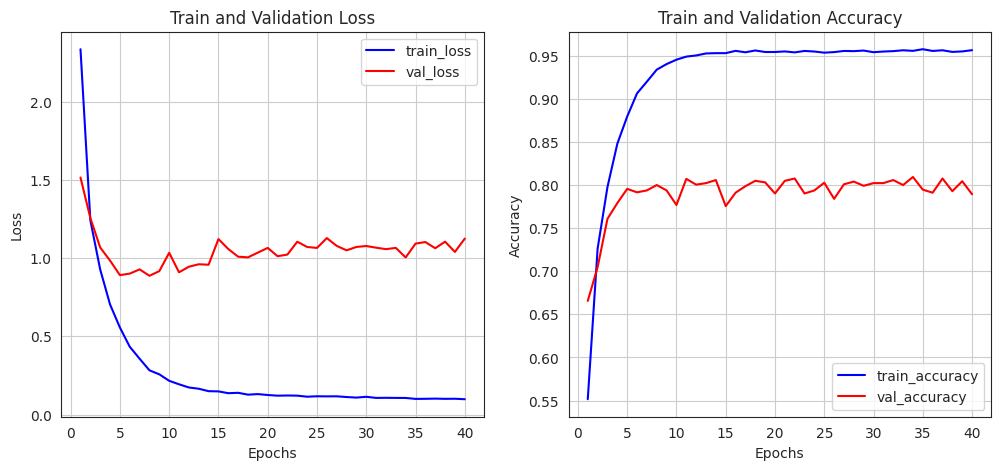

In [ ]:
import matplotlib.pyplot as plt

history_dict = history.history

loss = history_dict['loss']
val_loss = history_dict['val_loss']
epochs = range(1, len(loss) + 1)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color='blue', label='train_loss')
ax1.plot(epochs, val_loss, color='red', label='val_loss')
ax1.set_title('Train and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid()
ax1.legend()

accuracy = history_dict['accuracy']
val_accuracy = history_dict['val_accuracy']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, accuracy, color='blue', label='train_accuracy')
ax2.plot(epochs, val_accuracy, color='red', label='val_accuracy')
ax2.set_title('Train and Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid()
ax2.legend()

plt.show()

4.가중치 초기화

  Keras는 기본적으로 레이어에 균일분포 초기화를 수행하지만, 다른 초기화 방법과 비교해봄.

  이제 실제 Reuters 딥러닝 모델에 가중치 초기화를 적용한 결과를 살펴보기 위해 초기화 initializer에 따라 모델을 생성하는 build_model 함수를 정의.



In [ ]:
def build_model(initializer):
  model = models.Sequential()
  model.add(layers.Dense(128,
                         activation='relu',
                         kernel_initializer=initializer,
                         input_shape=(10000, ),
                         name='input'))
  model.add(layers.Dense(128,
                         activation='relu',
                         kernel_initializer=initializer,
                         name='hidden'))
  model.add(layers.Dense(46,
                         activation='softmax',
                         name='output'))
  model.compile(optimizer='rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])
  history = model.fit(x_train, y_train,
                    epochs=40,
                    batch_size=512,
                    validation_data=(x_test, y_test))
  return history

모델의 학습 히스토리 결과를 비교해보기 위해서 시각화하는 diff_history 함수를 정의






In [ ]:
def diff_history(history1, history2):
  history1_dict = history1.history
  h1_loss = history1_dict['loss']
  h1_val_loss = history1_dict['val_loss']

  history2_dict = history2.history
  h2_loss = history2_dict['loss']
  h2_val_loss = history2_dict['val_loss']

  epochs = range(1, len(h1_loss) + 1)
  fig = plt.figure(figsize=(12, 5))
  plt.subplots_adjust(wspace=0.3, hspace=0.3)

  ax1 = fig.add_subplot(1, 2, 1)
  ax1.plot(epochs, h1_loss, 'b-', label='train_loss')
  ax1.plot(epochs, h1_val_loss, 'r-', label='val_loss')
  ax1.plot(epochs, h2_loss, 'b--', label='train_loss')
  ax1.plot(epochs, h2_val_loss, 'r--', label='val_loss')
  ax1.set_title('Train and Validation Loss')
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Loss')
  ax1.grid()
  ax1.legend()

  h1_accuracy = history1_dict['accuracy']
  h1_val_accuracy = history1_dict['val_accuracy']

  h2_accuracy = history2_dict['accuracy']
  h2_val_accuracy = history2_dict['val_accuracy']

  ax2 = fig.add_subplot(1, 2, 2)
  ax2.plot(epochs, h1_accuracy, 'b-', label='train_accuracy')
  ax2.plot(epochs, h1_val_accuracy, 'r-', label='val_accuracy')
  ax2.plot(epochs, h2_accuracy, 'b--', label='train_accuracy')
  ax2.plot(epochs, h2_val_accuracy, 'r--', label='val_accuracy')
  ax2.set_title('Train and Validation Accuracy')
  ax2.set_xlabel('Epochs')
  ax2.set_ylabel('Accuracy')
  ax2.grid()
  ax2.legend()

  plt.show()

In [ ]:
# 제로 초기화  가중치 값을 0으로 초기화하는 모델을 생성하여 학습
zero_history = build_model(initializers.Zeros())

Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.0707 - loss: 3.8177 - val_accuracy: 0.3620 - val_loss: 3.7957
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.1926 - loss: 3.7894 - val_accuracy: 0.3620 - val_loss: 3.7729
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.3478 - loss: 3.7663 - val_accuracy: 0.3620 - val_loss: 3.7508
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.3551 - loss: 3.7443 - val_accuracy: 0.3620 - val_loss: 3.7290
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.3542 - loss: 3.7219 - val_accuracy: 0.3620 - val_loss: 3.7073
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.3519 - loss: 3.7000 - val_accuracy: 0.3620 - val_loss: 3.6858
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.3536 - loss: 3.6780 - val_accuracy: 0.3620 - val_loss: 3.6645
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.3509 - loss: 3.6572 - val_accuracy: 0.3620 - v

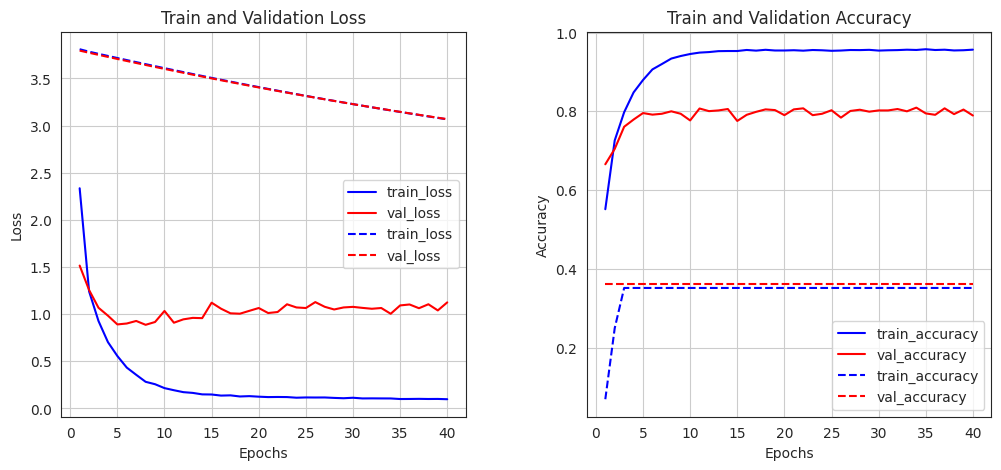

In [ ]:
# 기본 모델과 제로 초기화 모델 학습 결과를 비교하니, 제로 초기화 모델이 잘되고 있음이 확인됨

diff_history(history, zero_history)

In [ ]:
# 정규분포 초기화
normal_history = build_model(initializers.RandomNormal())

Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.3645 - loss: 2.8975 - val_accuracy: 0.6118 - val_loss: 1.6751
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.6518 - loss: 1.5338 - val_accuracy: 0.6768 - val_loss: 1.4028
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.7214 - loss: 1.2255 - val_accuracy: 0.7244 - val_loss: 1.2262
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.7750 - loss: 1.0010 - val_accuracy: 0.7467 - val_loss: 1.1304
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.8255 - loss: 0.7895 - val_accuracy: 0.7538 - val_loss: 1.0683
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.8506 - loss: 0.6621 - val_accuracy: 0.7640 - val_loss: 1.0087
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.8750 - loss: 0.5538 - val_accuracy: 0.7760 - val_loss: 0.9857
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.8937 - loss: 0.4732 - val_accuracy: 0.7787 - v

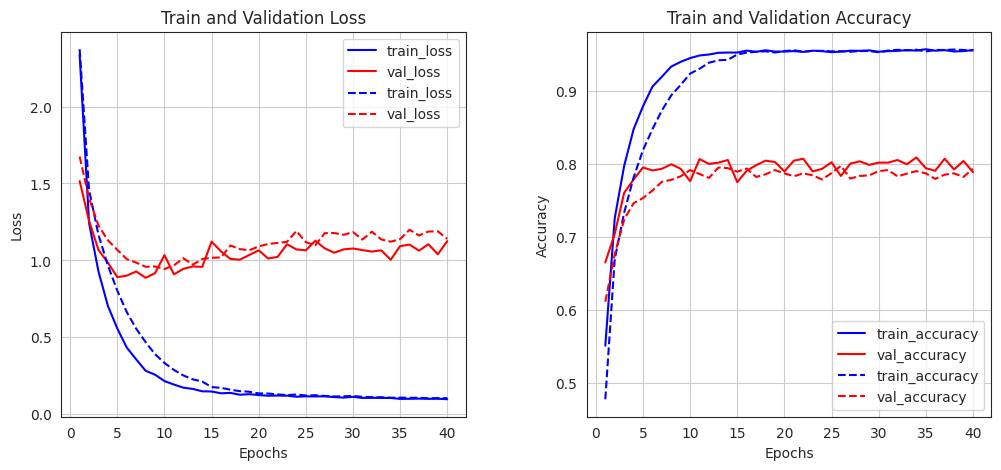

In [ ]:
# 정규분포로 초기화한 결과는 기본 모델과 유사하지만 조금 더디게 학습되고 있음이 확인됨
diff_history(history, normal_history)

In [ ]:
# Xavier(Glorot) 초기화
glorot_history = build_model(initializers.GlorotNormal())

Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.4271 - loss: 2.8431 - val_accuracy: 0.6581 - val_loss: 1.4890
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.7193 - loss: 1.2648 - val_accuracy: 0.7400 - val_loss: 1.1944
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.7994 - loss: 0.9309 - val_accuracy: 0.7560 - val_loss: 1.0574
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8384 - loss: 0.7249 - val_accuracy: 0.7778 - val_loss: 0.9701
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.8826 - loss: 0.5495 - val_accuracy: 0.7792 - val_loss: 0.9669
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9013 - loss: 0.4411 - val_accuracy: 0.7885 - val_loss: 0.9232
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9238 - loss: 0.3487 - val_accuracy: 0.7934 - val_loss: 0.9001
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9380 - loss: 0.2813 - val_accuracy: 0.8001 - v

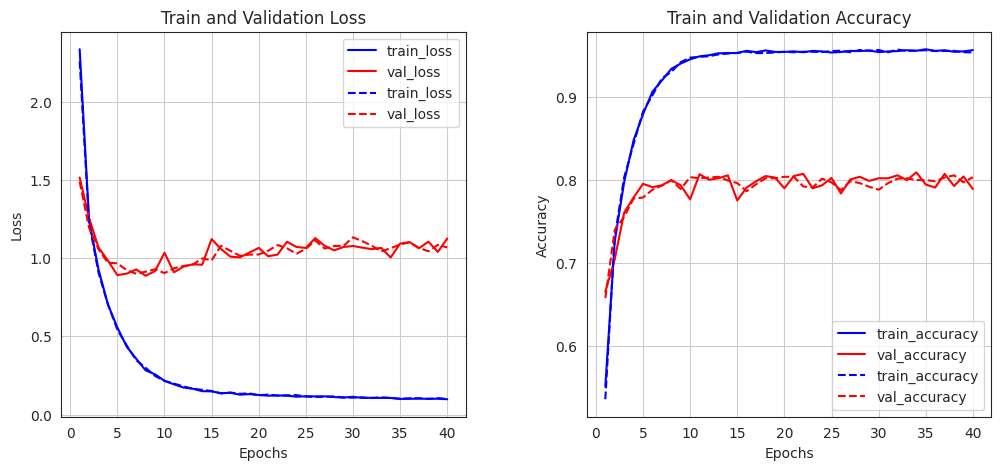

In [ ]:
# Xavier 초기화 방법은 기존 모델에서 사용하는 균일분포와 매우 유사한 형태로 학습됨.

diff_history(history, glorot_history)

In [ ]:
# He 초기화
he_history = build_model(initializers.HeNormal())

Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.4462 - loss: 2.8023 - val_accuracy: 0.6745 - val_loss: 1.4321
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.7384 - loss: 1.1812 - val_accuracy: 0.7382 - val_loss: 1.1499
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.8322 - loss: 0.7994 - val_accuracy: 0.7685 - val_loss: 1.0336
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8757 - loss: 0.5968 - val_accuracy: 0.7943 - val_loss: 0.9682
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9067 - loss: 0.4609 - val_accuracy: 0.7970 - val_loss: 0.8937
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9275 - loss: 0.3598 - val_accuracy: 0.8050 - val_loss: 0.8928
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.9410 - loss: 0.2754 - val_accuracy: 0.7965 - val_loss: 0.9023
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9447 - loss: 0.2343 - val_accuracy: 0.8094 - v

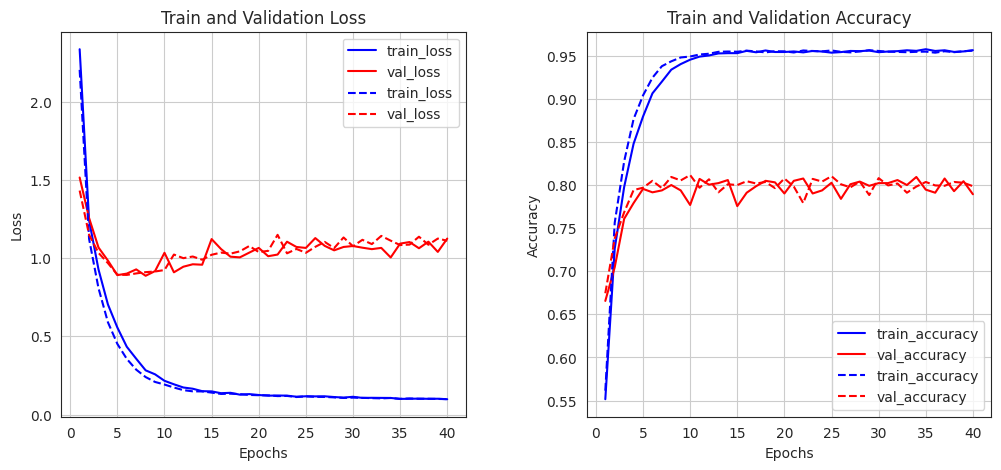

In [ ]:
# He 초기화는 기존 모델과 비교하여 작지만 좀 더 빠르게 학습됨.
# 현재 모델이 비선형 함수인 relu를 사용하여 He 초기화에 더 적합함.
diff_history(history, he_history)

# 10-4. Batch Normalization 배치 정규화

3.모델 구성 및 컴파일

  Reuters 데이터셋에 대해 뉴스 주제를 분류하는 딥러닝 모델에서 기존에 정의했던 3개의 Dense 레이어 사이에 배치 정규화를 위해 BatchNormalization() 레이어를 추가.
  
  다만 일반적으로 Dense 레이어와 Activation 활성함수 레이어 사이에 추가해아함.

In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers

model = models.Sequential()
model.add(layers.Dense(128, input_shape=(10000, ), name='input'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Dense(128, name='hidden'))
model.add(layers.BatchNormalization())
model.add(layers.Activation('relu'))
model.add(layers.Dense(46, activation='softmax', name='output'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (Dense)                   │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 46)             │         5,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,303,598 (4.97 MB)

 Trainable params: 1,303,086 (4.97 MB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
batch_norm_history = model.fit(x_train, y_train,
                               epochs=40,
                               batch_size=512,
                               validation_data=(x_test, y_test))

Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.5217 - loss: 2.3637 - val_accuracy: 0.7391 - val_loss: 3.3078
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.8797 - loss: 0.6571 - val_accuracy: 0.7395 - val_loss: 3.0673
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.9338 - loss: 0.3584 - val_accuracy: 0.7204 - val_loss: 2.7658
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.9549 - loss: 0.2192 - val_accuracy: 0.6937 - val_loss: 2.4398
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - accuracy: 0.9560 - loss: 0.1677 - val_accuracy: 0.7097 - val_loss: 2.1181
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.9632 - loss: 0.1301 - val_accuracy: 0.6630 - val_loss: 1.8246
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.9589 - loss: 0.1283 - val_accuracy: 0.7106 - val_loss: 1.5968
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.9606 - loss: 0.1105 - val_accuracy: 0.7333 

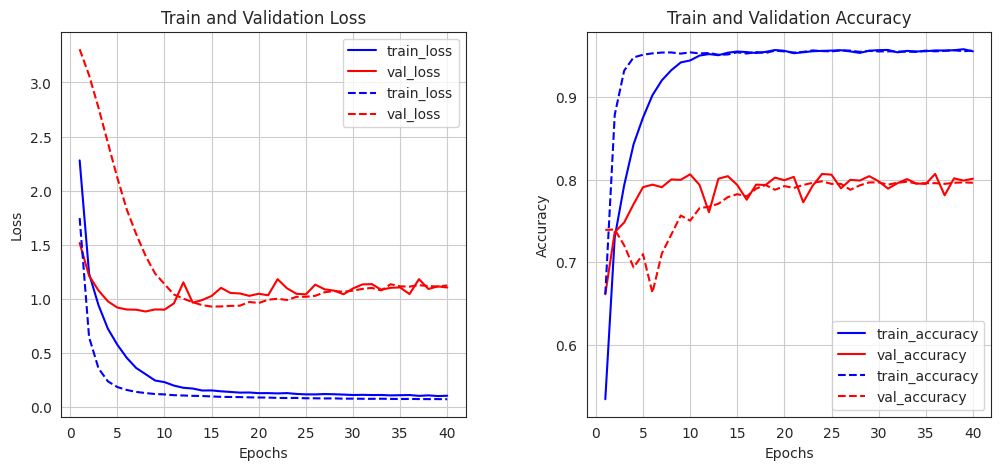

In [ ]:
# 기본 모델과 배치 정규화를 적용한 모델을 비교해보면, 배치 정규화를 적용한 모델이 좀 더 빠르고 안정되게 학습이 되고 있음
diff_history(history, batch_norm_history)

다만 배치 정규화에 대해선 아직도 밝혀지지 않은 부분이 많아 꾸준히 연구가 진행되고 있음

배치 정규화의 위치 역시 연구중인 분야로 활성화 함수 다음에 적용해야한다는 주장도 있음.

아래에서 활성화 함수 다음에 BatchNormalization() 레이어를 추가하고 성능을 비교

In [ ]:
# [play ground]

model = models.Sequential()
model.add(layers.Dense(128, input_shape=(10000, ), name='input'))

# 활성화 함수를 Dense 레이어와 같이 선언할 수도 있지만 단순히 위 코드에서 순서를 바꾸어도 동일하게 동작합니다.
model.add(layers.Activation('relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dense(128, name='hidden'))
model.add(layers.Activation('relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dense(46, activation='softmax', name='output'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (Dense)                   │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 46)             │         5,934 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,303,598 (4.97 MB)

 Trainable params: 1,303,086 (4.97 MB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
orderd_bn_history = model.fit(x_train, y_train,
                               epochs=40,
                               batch_size=512,
                               validation_data=(x_test, y_test))

Epoch 1/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.5259 - loss: 2.3150 - val_accuracy: 0.7364 - val_loss: 3.3560
Epoch 2/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.9087 - loss: 0.5244 - val_accuracy: 0.7427 - val_loss: 3.1914
Epoch 3/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.9462 - loss: 0.2823 - val_accuracy: 0.7476 - val_loss: 2.9786
Epoch 4/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.9559 - loss: 0.2010 - val_accuracy: 0.7484 - val_loss: 2.7466
Epoch 5/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.9560 - loss: 0.1654 - val_accuracy: 0.7449 - val_loss: 2.4972
Epoch 6/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.9573 - loss: 0.1421 - val_accuracy: 0.7609 - val_loss: 2.2375
Epoch 7/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.9584 - loss: 0.1334 - val_accuracy: 0.7600 - val_loss: 2.0216
Epoch 8/40
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.9551 - loss: 0.1338 - val_accuracy: 0.7783 